In [35]:
import lightgbm as lgb
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
import polars as pl
import numpy as np
import optuna
import pandas as pd

In [36]:
from pathlib import Path

path = Path.cwd()
if not Path(path, "data").exists():
    path = path.parent

### **Arquitectura: Modelo Hurdle de Dos Fases**

El **Modelo Hurdle** es una estrategia de modelado diseñada para datos con un **exceso de ceros** (zero-inflation), donde la decisión de que un evento ocurra es independiente de su magnitud. En este proyecto, desglosamos la predicción de propinas en dos etapas:

1. **Fase de Clasificación (La "Valla"):** Un modelo binario que determina la probabilidad de que un viaje genere propina ($P(\text{Tip} > 0)$). Esta fase captura factores de comportamiento y probabilidad base según el tipo de servicio (Taxi vs. VTC).
2. **Fase de Regresión (El "Experto"):** Un modelo de regresión entrenado exclusivamente en casos con propina positiva. Se encarga de estimar la cuantía económica basándose en variables de tarifa, distancia y geografía.



**Predicción Final:** La estimación final se obtiene calculando el valor esperado:
$$\text{Tip Final} = P(\text{Propina} > 0) \times \text{Monto Estimado}$$

Esta estructura permite que el regresor no sea "contaminado" por el gran volumen de viajes sin propina, logrando una especialización que optimiza la precisión en la estimación de los montos reales.

## Fase I: Predecir probabilidad de que no den tip (clasificador)

In [37]:
df_train = pl.scan_parquet(path / "data" / "train_tip_final_unificado_ligero.parquet")
df_val = pl.scan_parquet(path / "data" / "val_tip_final_unificado_ligero.parquet")

In [38]:
df_train = df_train.with_columns((pl.col("tip_amount") > 0).cast(pl.Int8).alias("has_tip"))
df_val = df_val.with_columns((pl.col("tip_amount") > 0).cast(pl.Int8).alias("has_tip"))

In [5]:
def añadir_pesos_dinamicos(df):
    """
    Calcula dinámicamente el peso de cada fila para equilibrar 
    las clases (tip 0 vs 1) de forma independiente para cada tipo de taxi.
    """
    
    # Calcular el peso usando la fórmula de frecuencia inversa
    df = df.with_columns(
        sample_weight = (
            pl.len().over("VendorID") / (2 * pl.len().over(["VendorID", "has_tip"]))
        )
    )
    
    return df

In [ ]:
df_train = añadir_pesos_dinamicos(df_train)
df_val = añadir_pesos_dinamicos(df_val)

In [40]:
df_train = df_train.collect()
df_val = df_val.collect()

In [ ]:
df_train.schema

Schema([('PULocationID', Int16),
        ('DOLocationID', Int16),
        ('tip_amount', Int16),
        ('VendorID', Int8),
        ('fare_amount', Int16),
        ('pickup_latitude', Float64),
        ('pickup_longitude', Float64),
        ('dropoff_latitude', Float64),
        ('dropoff_longitude', Float64),
        ('distance', Float64),
        ('direction', Float64),
        ('pickup_dist_nyc', Float64),
        ('dropoff_dist_nyc', Float64),
        ('pickup_dist_chp', Float64),
        ('dropoff_dist_chp', Float64),
        ('pickup_dist_exp', Float64),
        ('dropoff_dist_exp', Float64),
        ('temperature_2m', Float64),
        ('precipitation', Float64),
        ('rain', Float64),
        ('snowfall', Float64),
        ('temp_discomfort', Float64),
        ('daylight_duration', Float64),
        ('is_daylight', Int32),
        ('month', Int8),
        ('dayofyear', Int16),
        ('weekday', Int8),
        ('hour', Float64),
        ('has_tip', Int8),
        ('sample

In [42]:
categorical_cols = [
    "VendorID",
    "weekday",
    "month",
    "PULocationID",
    "DOLocationID",
    "is_daylight"
]
input_cols = [col for col in df_train.columns if col not in ["tip_amount", "has_tip", "sample_weight"]]
objective = "has_tip"

x_train, y_train = df_train.select(input_cols), df_train.select(objective).to_numpy()#, df_train.select("sample_weight").to_numpy().flatten()
x_val, y_val = df_val.select(input_cols), df_val.select(objective).to_numpy()

In [44]:
train_data = lgb.Dataset(
    data=x_train,
    label=y_train,
    feature_name=input_cols,
    categorical_feature=categorical_cols,
    #weight=weights_train,
    free_raw_data=True,
)

val_data = lgb.Dataset(
    data=x_val, label=y_val, reference=train_data, feature_name=input_cols
)

params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'learning_rate': 0.1,
    'verbose': -1
}

model_classif_lgb = lgb.train(
    params=params,
    train_set=train_data,
    num_boost_round=3000,
    valid_sets=[train_data, val_data],
    valid_names=["Entrenamiento", "Validacion"],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)],
)

Training until validation scores don't improve for 50 rounds
[100]	Entrenamiento's binary_logloss: 0.363373	Validacion's binary_logloss: 0.37844
[200]	Entrenamiento's binary_logloss: 0.361389	Validacion's binary_logloss: 0.377136
[300]	Entrenamiento's binary_logloss: 0.360011	Validacion's binary_logloss: 0.376347
[400]	Entrenamiento's binary_logloss: 0.359036	Validacion's binary_logloss: 0.375978
[500]	Entrenamiento's binary_logloss: 0.358132	Validacion's binary_logloss: 0.375636
[600]	Entrenamiento's binary_logloss: 0.357363	Validacion's binary_logloss: 0.375467
[700]	Entrenamiento's binary_logloss: 0.356702	Validacion's binary_logloss: 0.375424
Early stopping, best iteration is:
[656]	Entrenamiento's binary_logloss: 0.356975	Validacion's binary_logloss: 0.375412


In [59]:
model_classif_lgb.save_model(path / "data" / "lgbm_0.375412_tip_1stfase.txt")

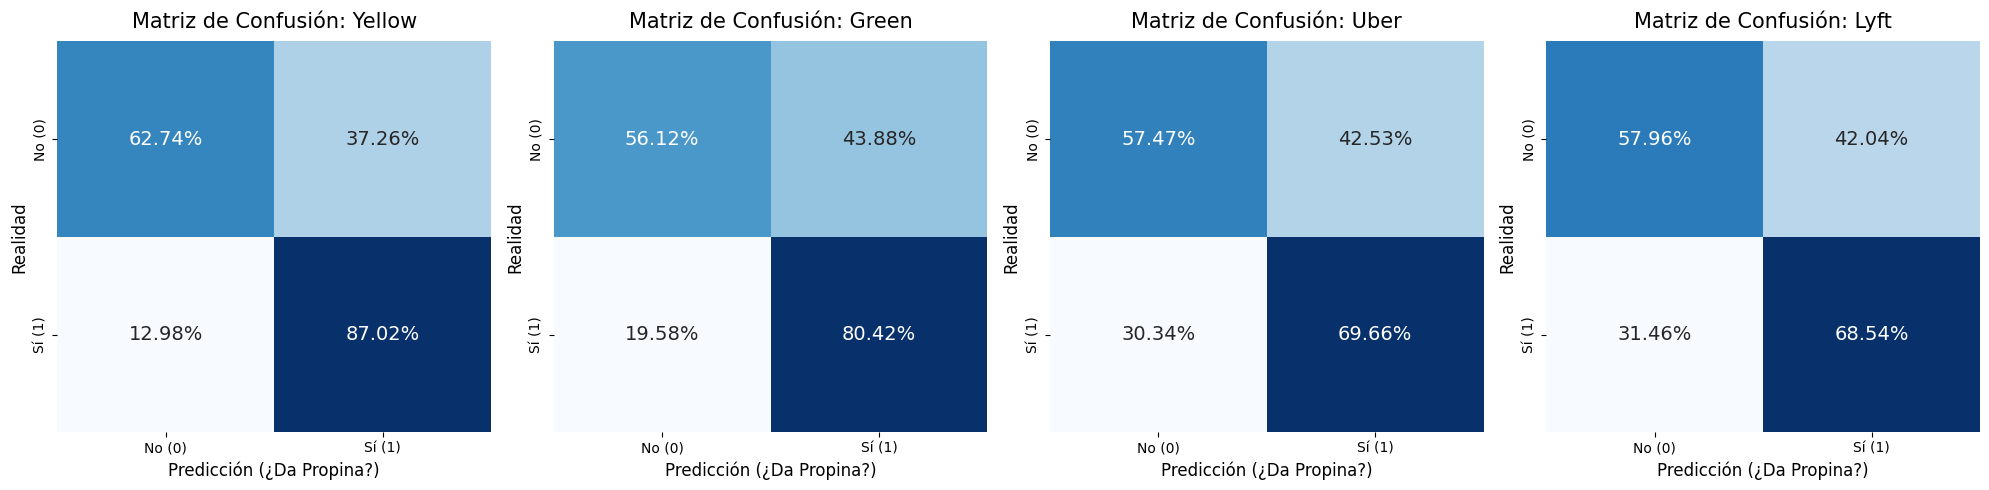


--- REPORTE PARA Yellow ---
              precision    recall  f1-score   support

           0       0.30      0.63      0.41      9704
           1       0.96      0.87      0.91    107602

    accuracy                           0.85    117306
   macro avg       0.63      0.75      0.66    117306
weighted avg       0.91      0.85      0.87    117306


--- REPORTE PARA Green ---
              precision    recall  f1-score   support

           0       0.21      0.56      0.30      2616
           1       0.95      0.80      0.87     28529

    accuracy                           0.78     31145
   macro avg       0.58      0.68      0.59     31145
weighted avg       0.89      0.78      0.82     31145


--- REPORTE PARA Uber ---
              precision    recall  f1-score   support

           0       0.89      0.57      0.70    126751
           1       0.27      0.70      0.39     28897

    accuracy                           0.60    155648
   macro avg       0.58      0.64      0.55 

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def plot_confusion_matrices(model, df_test, X_test_cols):
    """
    Genera matrices de confusión coloreadas por tipo de taxi.
    """
    preds_prob = model.predict(df_test[X_test_cols].to_pandas())
    preds_class = (preds_prob > 0.5).astype(int)
    
    df_eval = df_test.with_columns(
        pl.Series(name="pred", values=preds_class),
        pl.Series(name="target", values=df_test["has_tip"])
    ).to_pandas()

    taxis = df_eval['VendorID'].unique()
    n_taxis = len(taxis)
    dic_taxis = ["Yellow", "Green", "Uber", "Lyft"]

    fig, axes = plt.subplots(1, n_taxis, figsize=(5 * n_taxis, 5))
    if n_taxis == 1: axes = [axes] # Manejo de caso un solo taxi

    for i, taxi in enumerate(taxis):
        df_taxi = df_eval[df_eval['VendorID'] == taxi]
        
        cm = confusion_matrix(df_taxi['target'], df_taxi['pred'], normalize='true')
        
        # Dibujar con Seaborn
        sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', ax=axes[i], 
                    cbar=False, annot_kws={"size": 14})
        
        # Estética
        axes[i].set_title(f'Matriz de Confusión: {dic_taxis[taxi]}', fontsize=15, pad=10)
        axes[i].set_xlabel('Predicción (¿Da Propina?)', fontsize=12)
        axes[i].set_ylabel('Realidad', fontsize=12)
        axes[i].set_xticklabels(['No (0)', 'Sí (1)'])
        axes[i].set_yticklabels(['No (0)', 'Sí (1)'])

    plt.tight_layout()
    plt.show()

    # Imprimir reporte de métricas por consola para detalle técnico
    for taxi in taxis:
        df_taxi = df_eval[df_eval['VendorID'] == taxi]
        print(f"\n--- REPORTE PARA {dic_taxis[taxi]} ---")
        print(classification_report(df_taxi['target'], df_taxi['pred']))

plot_confusion_matrices(model_classif_lgb, df_val, input_cols)

## Fase II: Predecir la tip en sí

In [ ]:
df_train = pl.scan_parquet(path / "data" / "train_tip_final_unificado.parquet")
df_val = pl.scan_parquet(path / "data" / "val_tip_final_unificado.parquet")

In [ ]:
df_train = df_train.filter((pl.col("tip_amount") > 0) & (pl.col("fare_amount") > 0)).collect()
df_val = df_val.filter((pl.col("tip_amount") > 0) & (pl.col("fare_amount") > 0)).collect()

In [10]:
df_train.schema

Schema([('PULocationID', Int16),
        ('DOLocationID', Int16),
        ('tip_amount', Int16),
        ('VendorID', Int8),
        ('fare_amount', Int16),
        ('pickup_latitude', Float64),
        ('pickup_longitude', Float64),
        ('dropoff_latitude', Float64),
        ('dropoff_longitude', Float64),
        ('distance', Float64),
        ('direction', Float64),
        ('pickup_dist_nyc', Float64),
        ('dropoff_dist_nyc', Float64),
        ('pickup_dist_chp', Float64),
        ('dropoff_dist_chp', Float64),
        ('pickup_dist_exp', Float64),
        ('dropoff_dist_exp', Float64),
        ('temperature_2m', Float64),
        ('precipitation', Float64),
        ('rain', Float64),
        ('snowfall', Float64),
        ('temp_discomfort', Float64),
        ('daylight_duration', Float64),
        ('is_daylight', Int32),
        ('month', Int8),
        ('dayofyear', Int16),
        ('weekday', Int8),
        ('hour', Float64)])

In [ ]:
categorical_cols = [
    "VendorID",
    "weekday",
    "month",
    "PULocationID",
    "DOLocationID",
    "is_daylight"
]
input_cols = [col for col in df_train.columns if col not in ["tip_amount"]]
objective = "tip_amount"

x_train, y_train = df_train.select(input_cols), df_train.select(objective).to_numpy()
x_val, y_val = df_val.select(input_cols), df_val.select(objective).to_numpy()

### Prueba con rmse

In [ ]:
train_data = lgb.Dataset(
    data=x_train,
    label=y_train,
    feature_name=input_cols,
    categorical_feature=categorical_cols,
    free_raw_data=True,
)

val_data = lgb.Dataset(
    data=x_val, label=y_val, reference=train_data, feature_name=input_cols
)

lgbm_params = {
    "objective": "tweedie",
    "boosting": "gbdt",
    "metric": "rmse",
    "verbose": -1,
    "tweedie_variance_power": 1.55, 
    "learning_rate": 0.05, 
    "num_leaves": 150, 
    "max_depth": 10,
    "min_data_in_leaf": 1000, 
    "feature_fraction": 0.8, 
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l2": 1.0, 
    "max_bin": 255,
}

model_lgb = lgb.train(
    params=lgbm_params,
    train_set=train_data,
    num_boost_round=5000,
    valid_sets=[train_data, val_data],
    valid_names=["Entrenamiento", "Validacion"],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)],
)

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")


Training until validation scores don't improve for 50 rounds
[100]	Entrenamiento's rmse: 226.244	Validacion's rmse: 232.237
[200]	Entrenamiento's rmse: 224.983	Validacion's rmse: 231.888
[300]	Entrenamiento's rmse: 224.465	Validacion's rmse: 231.819
Early stopping, best iteration is:
[301]	Entrenamiento's rmse: 224.461	Validacion's rmse: 231.819


In [ ]:
model_lgb.save_model(path / "data" / "lgbm_rmse231.819_tip_2ndfase.txt")

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

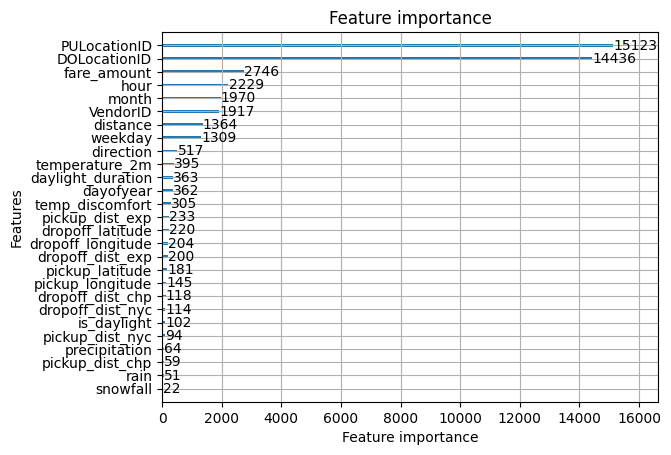

In [ ]:
lgb.plot_importance(model_lgb)

Prácticamente agrupa por origen y destino y predice la media, si bien las variables de tiempo y clima reducen incertidumbre.

In [ ]:
def evaluar_modelo(y_true, y_pred, nombre_set="Test"):
    """
    Evalúa predicciones de regresión y devuelve un diccionario con las métricas.
    Soporta entradas como Series de Polars, listas o arrays de NumPy.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    media_real = np.mean(y_true)
    media_pred = np.mean(y_pred)

    print(f"\n--- REPORTE DE RENDIMIENTO: {nombre_set} ---")
    print(f"MAE  (Error Absoluto Medio):       {mae:.4f}")
    print(f"RMSE (Raíz del Error Cuadrático):  {rmse:.4f}")
    print(f"R²   (Coef. de Determinación):     {r2:.4f}")
    print("-" * 45)
    print(f"Propina media real del set:        {media_real:.4f}")
    print(f"Propina media predicha:            {media_pred:.4f}")
    print("-" * 45)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Media_Real": media_real,
        "Media_Pred": media_pred,
    }

In [ ]:
predicciones = model_lgb.predict(x_val)
metricas_finales = evaluar_modelo(
    y_val, predicciones, nombre_set="Tip (val) con rmse segunda fase"
)

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")



--- REPORTE DE RENDIMIENTO: Tip (val) con rmse segunda fase ---
MAE  (Error Absoluto Medio):       127.2861
RMSE (Raíz del Error Cuadrático):  231.8186
R²   (Coef. de Determinación):     0.6952
---------------------------------------------
Propina media real del set:        494.8240
Propina media predicha:            487.9338
---------------------------------------------


## Comparación con baseline

In [45]:
df_train1 = pl.scan_parquet(path / "data" / "train_tip_final_unificado_ligero.parquet")

df_train1 = df_train1.with_columns((pl.col("tip_amount") > 0).cast(pl.Int8).alias("has_tip"))
df_train1 = añadir_pesos_dinamicos(df_train1).collect()

In [46]:
input_cols = [col for col in df_train1.columns if col not in ["tip_amount", "has_tip", "sample_weight"]]

In [47]:
df_train2 = pl.scan_parquet(path / "data" / "train_tip_final_unificado.parquet")

df_train2 = df_train2.filter((pl.col("tip_amount") > 0) & (pl.col("fare_amount") > 0)).collect()

In [48]:
df_test = pl.read_parquet(path / "data" / "train_tip_final_unificado_ligero.parquet")

In [49]:
print("Calculando la Baseline desde los datos de entrenamiento...")

# ==========================================
# 1. CONSTRUIR LA BASELINE (A partir del Train)
# ==========================================

# Fase 1 Baseline: Probabilidad histórica de propina por tipo de taxi
baseline_prob = df_train1.group_by("VendorID").agg(
    pl.col("has_tip").mean().alias("base_prob")
)

# Fase 2 Baseline: Media de propina por origen, destino y taxi (Solo donde hubo propina)
baseline_amount = (
    df_train2.group_by(["PULocationID", "DOLocationID", "VendorID"])
    .agg(pl.col("tip_amount").mean().alias("base_amount"))
)

# Media global por VendorID de "respaldo" (por si en el test sale una ruta que no vimos en el train)
baseline_amount_fallback = (
    df_train2.group_by("VendorID")
    .agg(pl.col("tip_amount").mean().alias("fallback_amount"))
)

# ==========================================
# 2. APLICAR BASELINE Y ML AL TEST SET
# ==========================================

print("Generando predicciones sobre el Test Set...")

# Unimos las reglas de la baseline al dataset de test
df_eval = (
    df_test.join(baseline_prob, on="VendorID", how="left")
    .join(baseline_amount, on=["PULocationID", "DOLocationID", "VendorID"], how="left")
    .join(baseline_amount_fallback, on="VendorID", how="left")
    # Si la ruta no existía en train, usamos el fallback
    .with_columns(
        base_amount = pl.col("base_amount").fill_null(pl.col("fallback_amount"))
    )
)

# Predicción Final Baseline: Probabilidad * Monto
df_eval = df_eval.with_columns(
    pred_baseline = pl.col("base_prob") * pl.col("base_amount")
)

Calculando la Baseline desde los datos de entrenamiento...
Generando predicciones sobre el Test Set...


In [60]:
# MODELO QUE PREDICE PROBABILIDAD DE DAR PROPINA
model_fase1 = lgb.Booster(model_file=path / "data" / "lgbm_0.375412_tip_1stfase.txt")

In [51]:
# MODELO QUE PREDICE LA PROPINA EN SÍ
model_fase2 = lgb.Booster(model_file=path / "data" / "lgbm_rmse231.819_tip_2ndfase.txt")

In [52]:
X_test = df_eval.select(input_cols).to_pandas()

ml_probs = model_fase1.predict(X_test)

ml_amounts = model_fase2.predict(X_test)

df_eval = df_eval.with_columns(
    ml_prob = pl.Series(ml_probs),
    ml_amount = pl.Series(ml_amounts)
).with_columns(
    pred_ml = pl.col("ml_prob") * pl.col("ml_amount")
)

In [58]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("\n" + "="*50)
print("EVALUACIÓN AISLADA DE LA FASE 2 (SOLO VIAJES CON PROPINA)")
print("="*50)

# Filtramos solo los casos donde la realidad es que SÍ hubo propina
mask_con_propina = df_pandas["tip_amount"] > 0
df_propina = df_pandas[mask_con_propina]

y_true_fase2 = df_propina["tip_amount"]

# Aislamos las predicciones (usamos ml_amount crudo, sin multiplicar por la probabilidad)
# Y lo comparamos con la baseline_amount (sin multiplicar)
rmse_base_fase2 = root_mean_squared_error(y_true_fase2, df_propina["base_amount"])
mae_base_fase2  = mean_absolute_error(y_true_fase2, df_propina["base_amount"])

rmse_ml_fase2 = root_mean_squared_error(y_true_fase2, df_propina["ml_amount"])
mae_ml_fase2  = mean_absolute_error(y_true_fase2, df_propina["ml_amount"])

print("\n[MÉTRICAS FASE 2 (REGRESOR PURO)]")
print(f"BASELINE EXPERTO -> RMSE: {rmse_base_fase2:.4f} | MAE: {mae_base_fase2:.4f}")
print(f"ML REGRESOR      -> RMSE: {rmse_ml_fase2:.4f} | MAE: {mae_ml_fase2:.4f}")

mejora_fase2 = ((rmse_base_fase2 - rmse_ml_fase2) / rmse_base_fase2) * 100
print(f"-> Mejora del Regresor ML sobre la Baseline: {mejora_fase2:.2f}% en RMSE")
dic_taxis = ["Yellow", "Green", "Uber", "Lyft"]

print("\n[DESGLOSE POR TIPO DE TAXI (FASE 2)]")
for taxi in df_propina['VendorID'].unique():
    mask_taxi = df_propina['VendorID'] == taxi
    rmse_b = root_mean_squared_error(y_true_fase2[mask_taxi], df_propina.loc[mask_taxi, "base_amount"])
    rmse_m = root_mean_squared_error(y_true_fase2[mask_taxi], df_propina.loc[mask_taxi, "ml_amount"])
    diff = rmse_b - rmse_m
    print(f"{dic_taxis[taxi].ljust(8)} | Baseline: {rmse_b:.4f} | ML: {rmse_m:.4f} | Dif: {diff:+.4f} (Positivo es mejor)")


EVALUACIÓN AISLADA DE LA FASE 2 (SOLO VIAJES CON PROPINA)

[MÉTRICAS FASE 2 (REGRESOR PURO)]
BASELINE EXPERTO -> RMSE: 257.4894 | MAE: 144.2749
ML REGRESOR      -> RMSE: 224.8507 | MAE: 119.4360
-> Mejora del Regresor ML sobre la Baseline: 12.68% en RMSE

[DESGLOSE POR TIPO DE TAXI (FASE 2)]
Yellow   | Baseline: 228.4318 | ML: 206.8993 | Dif: +21.5325 (Positivo es mejor)
Green    | Baseline: 241.2440 | ML: 223.2900 | Dif: +17.9540 (Positivo es mejor)
Uber     | Baseline: 335.4225 | ML: 270.4220 | Dif: +65.0006 (Positivo es mejor)
Lyft     | Baseline: 304.0111 | ML: 251.3935 | Dif: +52.6176 (Positivo es mejor)


In [57]:
# ==========================================
# 3. COMPARACIÓN DE MÉTRICAS (RMSE y MAE)
# ==========================================

print("\n" + "="*50)
print("COMPETICIÓN FINAL: ML HURDLE vs BASELINE")
print("="*50)

df_pandas = df_eval.to_pandas()
y_true = df_pandas["tip_amount"]

# Métricas Globales
rmse_base = root_mean_squared_error(y_true, df_pandas["pred_baseline"])
mae_base  = mean_absolute_error(y_true, df_pandas["pred_baseline"])

rmse_ml = root_mean_squared_error(y_true, df_pandas["pred_ml"])
mae_ml  = mean_absolute_error(y_true, df_pandas["pred_ml"])

print("\n[MÉTRICAS GLOBALES]")
print(f"BASELINE -> RMSE: {rmse_base:.4f} | MAE: {mae_base:.4f}")
print(f"ML MODEL -> RMSE: {rmse_ml:.4f} | MAE: {mae_ml:.4f}")

# Calcular el % de mejora
mejora_rmse = ((rmse_base - rmse_ml) / rmse_base) * 100
print(f"-> Mejora del ML sobre la Baseline: {mejora_rmse:.2f}% en RMSE")

dic_taxis = ["Yellow", "Green", "Uber", "Lyft"]
# Desglose por tipo de taxi
print("\n[DESGLOSE POR TIPO DE TAXI (RMSE)]")
for taxi in df_pandas['VendorID'].unique():
    mask = df_pandas['VendorID'] == taxi
    rmse_b = root_mean_squared_error(y_true[mask], df_pandas.loc[mask, "pred_baseline"])
    rmse_m = root_mean_squared_error(y_true[mask], df_pandas.loc[mask, "pred_ml"])
    diff = rmse_b - rmse_m
    print(f"{dic_taxis[taxi].ljust(8)} | Baseline: {rmse_b:.4f} | ML: {rmse_m:.4f} | Dif: {diff:+.4f} (Positivo es mejor)")


COMPETICIÓN FINAL: ML HURDLE vs BASELINE

[MÉTRICAS GLOBALES]
BASELINE -> RMSE: 278.2208 | MAE: 157.4533
ML MODEL -> RMSE: 257.7050 | MAE: 145.6160
-> Mejora del ML sobre la Baseline: 7.37% en RMSE

[DESGLOSE POR TIPO DE TAXI (RMSE)]
Yellow   | Baseline: 268.3438 | ML: 238.0782 | Dif: +30.2655 (Positivo es mejor)
Green    | Baseline: 276.7691 | ML: 251.2547 | Dif: +25.5144 (Positivo es mejor)
Uber     | Baseline: 277.8373 | ML: 262.1494 | Dif: +15.6879 (Positivo es mejor)
Lyft     | Baseline: 286.9307 | ML: 270.8158 | Dif: +16.1149 (Positivo es mejor)


In [54]:
print("\n" + "="*50)
print("COMPETICIÓN HÍBRIDA: (Probabilidad Histórica x Regresor ML) vs BASELINE TOTAL")
print("="*50)

# 1. Creamos la predicción híbrida:
# Multiplicamos la probabilidad de la baseline ('base_prob') 
# por la predicción de monto de tu ML ('ml_amount')
df_pandas["pred_hibrida"] = df_pandas["base_prob"] * df_pandas["ml_amount"]

# Aseguramos la variable real objetivo
y_true_global = df_pandas["tip_amount"]

# 2. Calculamos RMSE y MAE del modelo Híbrido
rmse_hibrido = root_mean_squared_error(y_true_global, df_pandas["pred_hibrida"])
mae_hibrido  = mean_absolute_error(y_true_global, df_pandas["pred_hibrida"])

# 3. Calculamos RMSE y MAE de la Baseline Total (Prob Base x Monto Base)
rmse_base_total = root_mean_squared_error(y_true_global, df_pandas["pred_baseline"])
mae_base_total  = mean_absolute_error(y_true_global, df_pandas["pred_baseline"])

# --- IMPRIMIR RESULTADOS ---
print("\n[MÉTRICAS GLOBALES (TODOS LOS VIAJES)]")
print(f"BASELINE TOTAL -> RMSE: {rmse_base_total:.4f} | MAE: {mae_base_total:.4f}")
print(f"MODELO HÍBRIDO -> RMSE: {rmse_hibrido:.4f} | MAE: {mae_hibrido:.4f}")

mejora_hibrida = ((rmse_base_total - rmse_hibrido) / rmse_base_total) * 100
print(f"\n-> Mejora del Modelo Híbrido sobre la Baseline: {mejora_hibrida:+.2f}% en RMSE")

dic_taxis = ["Yellow", "Green", "Uber", "Lyft"]
print("\n[DESGLOSE POR TIPO DE TAXI (RMSE)]")
for taxi in df_pandas['VendorID'].unique():
    mask = df_pandas['VendorID'] == taxi
    rmse_b = root_mean_squared_error(y_true_global[mask], df_pandas.loc[mask, "pred_baseline"])
    rmse_h = root_mean_squared_error(y_true_global[mask], df_pandas.loc[mask, "pred_hibrida"])
    diff = rmse_b - rmse_h
    print(f"{dic_taxis[taxi].ljust(8)} | Baseline: {rmse_b:.4f} | Híbrido: {rmse_h:.4f} | Dif: {diff:+.4f} (Positivo es mejor)")


COMPETICIÓN HÍBRIDA: (Probabilidad Histórica x Regresor ML) vs BASELINE TOTAL

[MÉTRICAS GLOBALES (TODOS LOS VIAJES)]
BASELINE TOTAL -> RMSE: 278.2208 | MAE: 157.4533
MODELO HÍBRIDO -> RMSE: 271.2770 | MAE: 152.9445

-> Mejora del Modelo Híbrido sobre la Baseline: +2.50% en RMSE

[DESGLOSE POR TIPO DE TAXI (RMSE)]
Yellow   | Baseline: 268.3438 | Híbrido: 253.5465 | Dif: +14.7973 (Positivo es mejor)
Green    | Baseline: 276.7691 | Híbrido: 269.6657 | Dif: +7.1035 (Positivo es mejor)
Uber     | Baseline: 277.8373 | Híbrido: 273.7700 | Dif: +4.0674 (Positivo es mejor)
Lyft     | Baseline: 286.9307 | Híbrido: 283.5845 | Dif: +3.3462 (Positivo es mejor)


In [56]:
print("\n" + "="*50)
print("COMPETICIÓN SOLO FASE II: SOLO Regresor ML vs BASELINE TOTAL")
print("="*50)

# 1. Creamos la predicción híbrida:
# Multiplicamos la probabilidad de la baseline ('base_prob') 
# por la predicción de monto de tu ML ('ml_amount')

# Aseguramos la variable real objetivo
y_true_global = df_pandas["tip_amount"]

# 2. Calculamos RMSE y MAE del modelo Híbrido
rmse_hibrido = root_mean_squared_error(y_true_global, df_pandas["ml_amount"])
mae_hibrido  = mean_absolute_error(y_true_global, df_pandas["ml_amount"])

# 3. Calculamos RMSE y MAE de la Baseline Total (Prob Base x Monto Base)
rmse_base_total = root_mean_squared_error(y_true_global, df_pandas["pred_baseline"])
mae_base_total  = mean_absolute_error(y_true_global, df_pandas["pred_baseline"])

# --- IMPRIMIR RESULTADOS ---
print("\n[MÉTRICAS GLOBALES (TODOS LOS VIAJES)]")
print(f"BASELINE TOTAL -> RMSE: {rmse_base_total:.4f} | MAE: {mae_base_total:.4f}")
print(f"MODELO FASEII -> RMSE: {rmse_hibrido:.4f} | MAE: {mae_hibrido:.4f}")

mejora_hibrida = ((rmse_base_total - rmse_hibrido) / rmse_base_total) * 100
print(f"\n-> Mejora del Modelo Híbrido sobre la Baseline: {mejora_hibrida:+.2f}% en RMSE")

dic_taxis = ["Yellow", "Green", "Uber", "Lyft"]
print("\n[DESGLOSE POR TIPO DE TAXI (RMSE)]")
for taxi in df_pandas['VendorID'].unique():
    mask = df_pandas['VendorID'] == taxi
    rmse_b = root_mean_squared_error(y_true_global[mask], df_pandas.loc[mask, "pred_baseline"])
    rmse_h = root_mean_squared_error(y_true_global[mask], df_pandas.loc[mask, "ml_amount"])
    diff = rmse_b - rmse_h
    print(f"{dic_taxis[taxi].ljust(8)} | Baseline: {rmse_b:.4f} | Solo FaseII: {rmse_h:.4f} | Dif: {diff:+.4f} (Positivo es mejor)")


COMPETICIÓN SOLO FASE II: SOLO Regresor ML vs BASELINE TOTAL

[MÉTRICAS GLOBALES (TODOS LOS VIAJES)]
BASELINE TOTAL -> RMSE: 278.2208 | MAE: 157.4533
MODELO FASEII -> RMSE: 427.3938 | MAE: 301.7949

-> Mejora del Modelo Híbrido sobre la Baseline: -53.62% en RMSE

[DESGLOSE POR TIPO DE TAXI (RMSE)]
Yellow   | Baseline: 268.3438 | Solo FaseII: 257.1556 | Dif: +11.1881 (Positivo es mejor)
Green    | Baseline: 276.7691 | Solo FaseII: 277.5551 | Dif: -0.7860 (Positivo es mejor)
Uber     | Baseline: 277.8373 | Solo FaseII: 489.6826 | Dif: -211.8452 (Positivo es mejor)
Lyft     | Baseline: 286.9307 | Solo FaseII: 505.6444 | Dif: -218.7137 (Positivo es mejor)


Conclusiones: HA SIDO UN ÉXITO. La faseII es un 12.68% mejor en RMSE comparado con agrupar por Zona y Tipo de Taxi y predecir la media (comparativa hecha solo sobre viajes que dieron propina).

Por otro lado, se predice sobre el conjunto completo cogiendo la probabilidad de la faseI * tip faseII. Esto se compara multiplicando la baseline * la probabilidad de dejar propina por tipo de taxi (agrupar y hacer mean). La mejora del modelo es de un 7.37% en RMSE. Lo cuál está bastante bien teniendo en cuenta que si sustituimos la faseI por la baseline la mejora solo sería del 2.50% en RMSE y si solo predijéramos con la faseII sería un -53.62% peor en RMSE.